# Scale workflow: subsample + project for large datasets

For datasets in the hundreds-of-millions to billions of molecules range (e.g. a Xenium 5k panel × 2M cells, expected ~300M – 1B detections), running NMF + CRF on the full transcript table in one go is impractical: the per-molecule `W` matrix and the molecule-KNN BP message tensor exceed single-GPU memory.

The standard workaround — used by R `cellAdmix` via `nmol_dsamp`, and now in pycelladmix as a first-class workflow — is **subsample-and-project**:

1. **Subsample** ~1–2M molecules with cell-type-balanced sampling.
2. **Fit NMF** on the subsample → `H_admix` (frozen factor-by-gene basis).
3. **Annotate** factors via marker-enrichment to identify which factors represent admixture, per cell type.
4. **Project** soft per-molecule loadings on the full dataset using the frozen `H_admix`. This is a sparse-matrix matmul, much cheaper than re-fitting NMF.
5. **Aggregate** per-molecule loadings to a per-cell prior `W_admix` (n_cells × k_admix).
6. **Subtract** `W_admix @ H_admix` from observed counts → cleaned counts ready for downstream pipelines.

This tutorial demonstrates the full workflow on the MERFISH mouse hypothalamus dataset (~6.6 k cells × 1.4 M molecules in one Bregma slice) — small enough for a tutorial, large enough that the subsample-and-project pattern is meaningful. The same code scales to Xenium 5k × 2 M cells with the same API, just with larger `subsample_n` and chunked projection (each cell is processed independently in `project_per_molecule_loadings`).

The output is a **cleaned `(n_genes, n_cells)` counts matrix** that you can drop into Stormi, scanpy, or any downstream tool that consumes counts.

In [1]:
from __future__ import annotations

import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import squidpy as sq
from scipy import sparse

import pycelladmix
from pycelladmix.annotation import (
    aggregate_to_admix_prior,
    factors_to_remove_per_celltype,
    run_enrichment_test,
)
from pycelladmix.correction import admixture_count_summary, cleaned_counts_matrix
from pycelladmix.nmf import project_per_molecule_loadings, run_knn_nmf
from pycelladmix.preprocessing import transcript_counts_matrix

print(f"pycelladmix {pycelladmix.__version__} on JAX backend {jax.default_backend()}")

pycelladmix 0.1.0 on JAX backend gpu


## 1. Load + simulate molecule positions

Same setup as tutorial 03: real MERFISH counts, simulated within-cell positions. We keep the full Bregma slice (~6.6 k cells, ~1.4 M molecules) — *not* subsampled. The subsample comes later, inside the workflow.

In [2]:
%%time
adata = sq.datasets.merfish()
counts = adata.obs.groupby(["Animal_ID", "Bregma"]).size()
animal, bregma = counts.idxmax()
mask = (adata.obs["Animal_ID"] == animal) & (adata.obs["Bregma"] == bregma)
ad = adata[mask].copy()

class_counts = ad.obs["Cell_class"].value_counts()
keep_classes = class_counts.index[class_counts >= 50].tolist()
ad.obs["class"] = np.where(ad.obs["Cell_class"].isin(keep_classes), ad.obs["Cell_class"], "Other")

rng = np.random.default_rng(0)
gene_names = ad.var_names.to_numpy().tolist()
cm = ad.X if not sparse.issparse(ad.X) else ad.X.toarray()
cm = np.asarray(cm)

sigma_xy = 5.0
rows = []
mol_id_counter = 0
for ci in range(ad.n_obs):
    cell_name = ad.obs_names[ci]
    cx = float(ad.obs["Centroid_X"].iloc[ci])
    cy = float(ad.obs["Centroid_Y"].iloc[ci])
    ct = ad.obs["class"].iloc[ci]
    counts = cm[ci]
    for gi in np.flatnonzero(counts):
        n = int(counts[gi])
        if n == 0:
            continue
        gene = gene_names[gi]
        xs = cx + rng.normal(0, sigma_xy, size=n)
        ys = cy + rng.normal(0, sigma_xy, size=n)
        zs = rng.normal(0, 0.5, size=n)
        for x, y, z in zip(xs, ys, zs, strict=True):
            rows.append({"x": x, "y": y, "z": z, "gene": gene, "cell": cell_name, "celltype": ct,
                         "mol_id": f"m{mol_id_counter:08d}"})
            mol_id_counter += 1

df = pd.DataFrame(rows)
print(f"Full dataset: {len(df):,} molecules, {df['cell'].nunique():,} cells, {df['gene'].nunique()} genes")

Full dataset: 1,412,238 molecules, 6,605 cells, 158 genes
CPU times: user 18.4 s, sys: 1.62 s, total: 20.1 s
Wall time: 23.2 s


## 2. Subsample with cell-type balance, then fit NMF

`run_knn_nmf` accepts `nmol_dsamp` to downsample molecules before fitting. We pair it with `balance_cell_types` to first prune to a cell-type-balanced cell pool (so dominant types don't drown out rare ones in the NMF). For Xenium 5k × 2M cells, set `subsample_target=1_500_000` and the same call works — only the wall-clock changes.

In [3]:
%%time
SUBSAMPLE_N = 200_000  # tutorial-scale; for 2M-cell Xenium, use 1_500_000

# Subsample at the molecule level, biased toward balancing cell types.
df_sub = pycelladmix.preprocessing.balance_cell_types(
    df, num_cells_samp=2000, rng=np.random.default_rng(0)
)
if len(df_sub) > SUBSAMPLE_N:
    df_sub = df_sub.sample(n=SUBSAMPLE_N, random_state=0).reset_index(drop=True)
print(f"Subsampled to {len(df_sub):,} molecules across {df_sub['cell'].nunique():,} cells")
print(f"Cell-type balance after sampling:")
print(df_sub.groupby('celltype').size())

Subsampled to 200,000 molecules across 1,728 cells
Cell-type balance after sampling:
celltype
Ambiguous        20661
Astrocyte        20352
Endothelial 1    20995
Endothelial 3    11183
Ependymal        20938
Excitatory       20752
Inhibitory       20096
Microglia        13313
OD Immature 1    20598
OD Mature 2      20859
Other            10253
dtype: int64
CPU times: user 567 ms, sys: 72.8 ms, total: 640 ms
Wall time: 647 ms


In [4]:
%%time
res = run_knn_nmf(
    df_sub,
    k=8,
    h=15,
    n_runs=3,
    n_iter=200,
    seed=0,
    weighted=True,
)
print(f"Fit NMF on subsample: H = {res.H.shape}, recon err = {res.reconstruction_error:.0f}")
print(f"H_admix is now frozen — we'll use it to score the full dataset.")

Fit NMF on subsample: H = (8, 151), recon err = 180
H_admix is now frozen — we'll use it to score the full dataset.
CPU times: user 29 s, sys: 2.57 s, total: 31.6 s
Wall time: 25 s


## 3. Annotate factors via marker enrichment

Identify which factors represent admixture for each cell type. The marker set here is "any gene whose mean expression in cell type `t` is at least 3× the cell-type-wide mean" — a quick heuristic; in production use a curated marker list.

In [5]:
# Build markers from the RNA reference itself.
ad_class = ad.obs["class"].to_numpy()
cm_full = cm  # (n_cells, n_genes)
gene_arr = np.asarray(gene_names)

types = sorted(np.unique(ad_class))
markers = {}
for t in types:
    mask_t = ad_class == t
    if mask_t.sum() < 10:
        continue
    mean_t = cm_full[mask_t].mean(axis=0)
    mean_other = cm_full[~mask_t].mean(axis=0)
    is_marker = (mean_t > 0.5) & (mean_t > 3.0 * np.maximum(mean_other, 0.05))
    markers[t] = gene_arr[is_marker].tolist()
print("Markers per cell type (count):")
for t, m in markers.items():
    print(f"  {t:25s} {len(m):3d}")

Markers per cell type (count):
  Ambiguous                   1
  Astrocyte                   8
  Endothelial 1              10
  Endothelial 3               8
  Ependymal                  10
  Excitatory                  7
  Inhibitory                  5
  Microglia                   4
  OD Immature 1               7
  OD Mature 2                10
  Other                      12


In [6]:
%%time
enr = run_enrichment_test(res, markers, n_perm=2000, p_thresh=0.05, seed=0)

# For each factor, the cell type with the highest observed_frac is its "home"
# (the cell type the factor genuinely represents). Significant enrichments in
# *other* cell types flag this factor as admixture for those types.
admixture_factors = factors_to_remove_per_celltype(enr)
print("Admixture factors per cell type:")
for ct, fs in admixture_factors.items():
    print(f"  {ct:25s} {fs}")

Admixture factors per cell type:
  Endothelial 1             [8]
  Endothelial 3             [3, 7]
  Ependymal                 [6]
  Other                     [1]
CPU times: user 11.1 s, sys: 1.11 s, total: 12.2 s
Wall time: 14.3 s


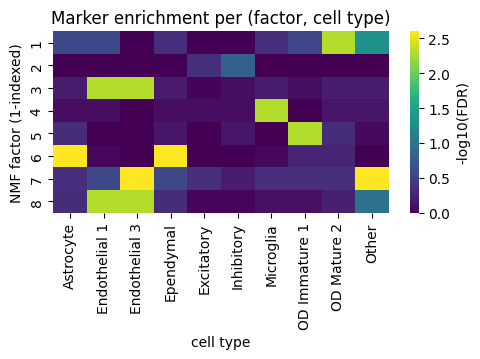

In [7]:
# Heatmap of -log10(FDR) per (factor, cell-type)
pivot = enr.pivot(index="factor", columns="cell_type", values="fdr").fillna(1.0)
log_pivot = -np.log10(pivot.clip(lower=1e-3))
fig, ax = plt.subplots(figsize=(0.5 + 0.45 * pivot.shape[1], 0.5 + 0.4 * pivot.shape[0]))
sns.heatmap(log_pivot, cmap="viridis", ax=ax, cbar_kws={"label": "-log10(FDR)"})
ax.set_title("Marker enrichment per (factor, cell type)")
ax.set_xlabel("cell type")
ax.set_ylabel("NMF factor (1-indexed)")
plt.tight_layout()
plt.show()

## 4. Project soft loadings on the full dataset

`H_admix` is frozen; `project_per_molecule_loadings` walks the full transcript table cell-by-cell, builds a sparse KNN-aggregated count matrix, and projects each row onto `H_admix` via the closed-form pseudoinverse `W = ReLU(X @ H+)`. No re-fitting; this is throughput-bound and embarrassingly parallel.

In [8]:
%%time
W_full, mol_ids_full = project_per_molecule_loadings(
    df, H=res.H, gene_names=list(res.gene_names), h=15, include_self=True,
)
print(f"Projected loadings: shape = {tuple(W_full.shape)} ({len(mol_ids_full):,} molecules)")
print(f"  per-factor mean:  {np.asarray(W_full).mean(axis=0).round(3)}")

Projected loadings: shape = (1412159, 8) (1,412,159 molecules)
  per-factor mean:  [0.035 0.196 0.03  0.012 0.028 0.05  0.011 0.014]
CPU times: user 51.9 s, sys: 2.11 s, total: 54 s
Wall time: 51.4 s


## 5. Aggregate to per-cell admixture prior

`aggregate_to_admix_prior` collapses the per-molecule loadings to a per-cell × per-admixture-factor matrix. Crucially, it **masks** entries cell-type-by-cell-type: cell `c` of type `t` only gets non-zero loading on factor `f` if `f ∈ admixture_factors[t]` (i.e. that factor is flagged as admixture for that cell's type). This prevents the prior from claiming "this cell has admixture from factor X" when factor X is actually X's own native signature.

In [9]:
W_admix, H_admix, cell_names_admix, gene_names_admix, admix_factor_ids = aggregate_to_admix_prior(
    df,
    W_per_molecule=W_full,
    mol_ids=mol_ids_full,
    H=res.H,
    gene_names=list(res.gene_names),
    admixture_factors=admixture_factors,
)
print(f"W_admix shape: {W_admix.shape}  (n_cells × k_admix)")
print(f"H_admix shape: {H_admix.shape}  (k_admix × n_genes)")
print(f"Admixture factor ids retained: {admix_factor_ids.tolist()}")
nz = (W_admix > 0).any(axis=1).sum()
print(f"Cells with at least one non-zero admixture loading: {nz}/{len(cell_names_admix)} "
      f"({100*nz/len(cell_names_admix):.1f}%)")

W_admix shape: (6605, 5)  (n_cells × k_admix)
H_admix shape: (5, 151)  (k_admix × n_genes)
Admixture factor ids retained: [1, 3, 6, 7, 8]
Cells with at least one non-zero admixture loading: 765/6605 (11.6%)


## 6. Cleaned counts matrix

`cleaned_counts_matrix` computes `max(observed - W_admix @ H_admix, 0)` (with optional per-entry capping at observed counts) and returns a sparse matrix in the same orientation as the input. This is the **v1 deliverable** for the Stormi sequential pipeline: feed `cleaned` into Stormi as the observed RNA counts; no model changes needed.

In [10]:
# Build observed counts matrix in (genes × cells) orientation matching cell_names_admix order.
cm_obs, gene_names_obs, cell_names_obs = transcript_counts_matrix(df)

# Reorder W_admix rows to match cell_names_obs order (transcript_counts_matrix sorts cells alphabetically).
cell_to_idx = {c: i for i, c in enumerate(cell_names_admix)}
order = np.asarray([cell_to_idx[c] for c in cell_names_obs])
W_admix_ordered = W_admix[order]

# Restrict H_admix and observed to the common gene set.
common = sorted(set(gene_names_obs) & set(gene_names_admix.tolist()))
g_obs_to_i = {g: i for i, g in enumerate(gene_names_obs.tolist())}
g_admix_to_i = {g: i for i, g in enumerate(gene_names_admix.tolist())}
obs_idx = [g_obs_to_i[g] for g in common]
adm_idx = [g_admix_to_i[g] for g in common]
cm_obs_g = cm_obs[obs_idx]
H_admix_g = H_admix[:, adm_idx]

cleaned = cleaned_counts_matrix(
    cm_obs_g, W_admix_ordered, H_admix_g, cell_axis="columns",
)
print(f"Observed counts: {cm_obs_g.shape}, total = {int(cm_obs_g.sum()):,}")
print(f"Cleaned counts:  {cleaned.shape}, total = {int(cleaned.sum()):,}")
print(f"Total counts removed: {int(cm_obs_g.sum() - cleaned.sum()):,} "
      f"({100 * (cm_obs_g.sum() - cleaned.sum()) / cm_obs_g.sum():.2f}%)")

Observed counts: (151, 6605), total = 1,412,159
Cleaned counts:  (151, 6605), total = 1,332,837
Total counts removed: 79,321 (5.62%)


Per-cell admixture-removal stats by cell type:
               observed_total  admix_removed  frac_removed
celltype                                                  
Ambiguous          225.604004          0.000         0.000
Astrocyte          165.085007          0.000         0.000
Endothelial 1      227.852005         54.311         0.252
Endothelial 3      188.056000         63.202         0.320
Ependymal          193.139008        179.123         0.927
Excitatory         218.070999          0.000         0.000
Inhibitory         220.947006          0.000         0.000
Microglia          169.957001          0.000         0.000
OD Immature 1      236.451996          0.000         0.000
OD Mature 2        258.673004          0.000         0.000
Other              178.417007         76.776         0.475


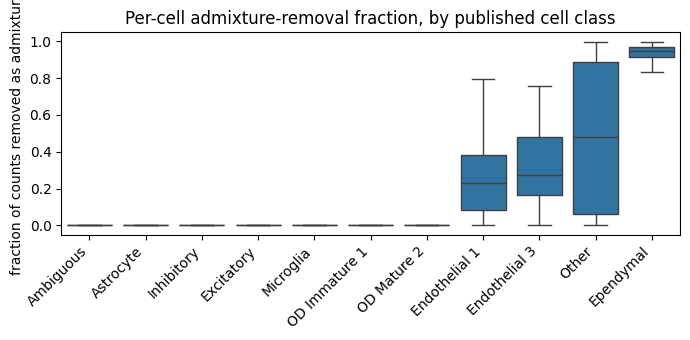

In [11]:
summary = admixture_count_summary(W_admix_ordered, H_admix_g, cm_obs_g, cell_axis="columns")
summary.index = list(cell_names_obs)
summary["celltype"] = ad.obs.set_index(ad.obs_names)["class"].reindex(summary.index).to_numpy()

print("Per-cell admixture-removal stats by cell type:")
by_ct = summary.groupby("celltype")[["observed_total", "admix_removed", "frac_removed"]].mean()
print(by_ct.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
order = by_ct.sort_values("frac_removed", ascending=True).index.tolist()
sns.boxplot(
    data=summary.dropna(subset=["frac_removed"]),
    x="celltype", y="frac_removed",
    order=order, ax=ax, showfliers=False,
)
ax.set_ylabel("fraction of counts removed as admixture")
ax.set_xlabel("")
ax.set_title("Per-cell admixture-removal fraction, by published cell class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

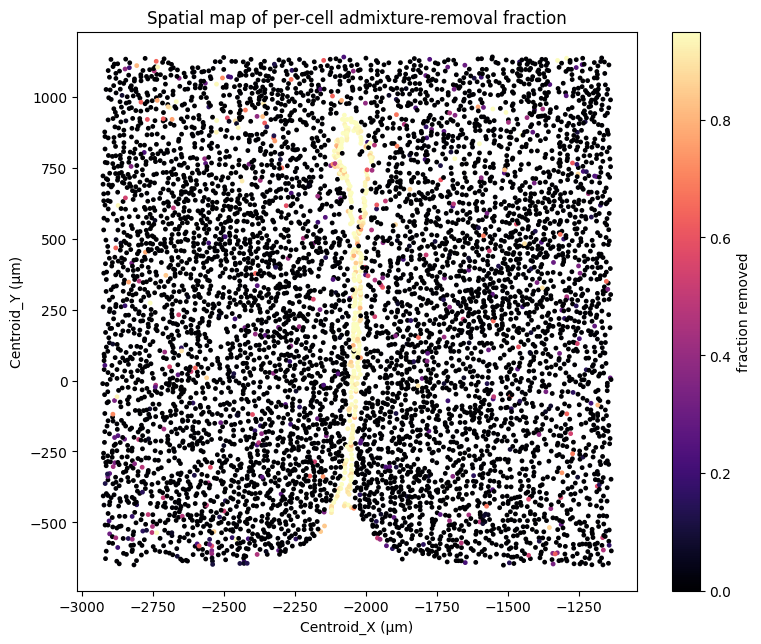

In [12]:
# Spatial map: per-cell admixture fraction overlaid on the slice geometry.
keep = summary["observed_total"] > 0
fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(
    ad.obs.loc[summary.index[keep], "Centroid_X"],
    ad.obs.loc[summary.index[keep], "Centroid_Y"],
    c=summary.loc[keep, "frac_removed"],
    s=6, cmap="magma",
    vmin=0, vmax=float(np.nanquantile(summary["frac_removed"], 0.98)),
)
ax.set_aspect("equal")
ax.set_xlabel("Centroid_X (µm)")
ax.set_ylabel("Centroid_Y (µm)")
ax.set_title("Spatial map of per-cell admixture-removal fraction")
plt.colorbar(sc, ax=ax, label="fraction removed")
plt.tight_layout()
plt.show()

## 7. Feeding the result downstream

The `cleaned` matrix (and the original `W_admix`, `H_admix`) is now ready for the Stormi sequential workflow:

```python
import anndata as ad

ad_cleaned = ad.AnnData(
    X=cleaned.T.tocsr(),       # (n_cells, n_genes) — scanpy/scverse convention
    obs=ad.obs.loc[cell_names_obs].copy(),
    var=ad.var.loc[gene_names_obs[obs_idx]].copy(),
)
ad_cleaned.layers["counts_original"] = cm_obs_g.T.tocsr()
ad_cleaned.obsm["W_admix"] = W_admix_ordered
ad_cleaned.uns["H_admix"] = H_admix_g
ad_cleaned.uns["admix_factor_ids"] = admix_factor_ids
# Now hand `ad_cleaned` to Stormi or any other counts-driven pipeline.
```

Storing `W_admix` and `H_admix` alongside the cleaned counts means a future Stormi-joint version (which would refine `W_admix_post` rather than freezing it) can pick up the prior directly from the AnnData.

## Scaling notes for Xenium 5k × 2M cells

- Step 2 (`balance_cell_types` + sample): bump `subsample_target` to ~1.5M molecules. Cell-type balancing matters more on Xenium because rare types are rarer and the panel is broader.
- Step 4 (`project_per_molecule_loadings`): cell-by-cell, so memory stays bounded; total time is roughly proportional to the number of molecules. With 600M molecules, expect ~10–20 minutes on an H100.
- Step 6 (`cleaned_counts_matrix`): produces a `(5000, 2_000_000)` matrix. If memory is tight, chunk by cell columns; the function accepts sparse input/output.